# Fotoğraflardaki El Yazısı Rakamları Otomatik Tanıma ve Anlamdırma

Projemizde kullandığımız MNIST elyazısı rakamları veritabanındaki(sklearn içinde gelmektedir) 784 feature sütunu mevcut (784 dimensions), ve training set olarak 60000 örnek veri ve 10000 örneklik test seti bulunmaktadır.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import fetch_openml # nmist datasetini yüklemek için gerekli...
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

mnist=fetch_openml('mnist_784')

In [2]:
mnist.data.shape

(70000, 784)

Mnist veriseti içindeki rakam fotoğraflarını görmek için bir fonksiyon tanımlayalım:

In [3]:
#parametre olarak dataframe ve ilgili veri fotoğrafının index numarasını alsın..
def showimage(dframe,index):
    some_digit=dframe.to_numpy()[index]
    some_digit_image=some_digit.reshape(28,28)

    plt.imshow(some_digit_image,cmap="binary")
    plt.axis("off")
    plt.show()

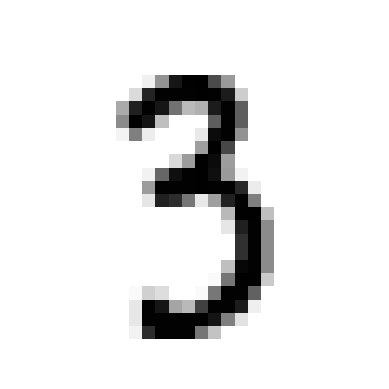

In [7]:
#örnek kullanım:
showimage(mnist.data,98)

Split Data -> Training Set ve Test Set

In [8]:
#test ve train oranı 1/7 ve 6/7
train_img,test_img,train_lbl,test_lbl=train_test_split(mnist.data,mnist.target,test_size=1/7.0,random_state=0)

In [9]:
type(train_img)

pandas.core.frame.DataFrame

In [10]:
#Rakam tahminlerimizi check etmek için train_img dataframeini kopyalıyoruz, çünkü az sonra değişecek..
test_img_copy=test_img.copy()

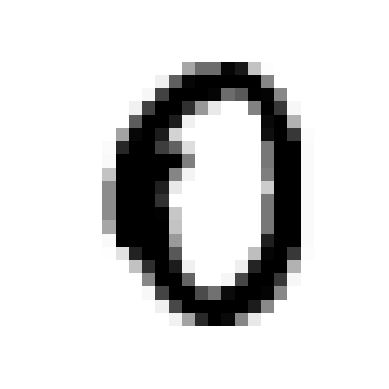

In [11]:
showimage(test_img_copy,0)

### Verilemizi Scale etmemiz gerekiyor:

Çünkü PCA scale edilmemiş verilerde hatalı sonuç verebiliyor bu nedenle mutlaka scalling işleminden geçiyoruz. Bu amaçla da StandarScale kullanıyoruz.

In [12]:
scaler=StandardScaler() #veri setini ölçeklendirmek için standartlaştırma tekniği kullanıyoruz, çünkü PCA ölçeklendirmeye duyarlıdır.

#scaler'ı sadece trainig set üzerinde fit yapmamız yeterli..
scaler.fit(train_img)

#Ama transform işlemini hem training sete hen de test sete yapmamız gerekiyor..
train_img=scaler.transform(train_img)
test_img=scaler.transform(test_img)

### PCA işlemini uyguluyoruz
variance'ın 95% oranında korunmasını istediğimizi belirtiyoruz.

In [13]:
#make an instance of the Model
pca=PCA(.95) #veri setinin %95'ini koruyacak şekilde PCA uygulayacağız.

In [14]:
#PCA'i sadece training sete yapmamız yeterli:(1dk sürebilir)
pca.fit(train_img)

PCA(n_components=0.95)

In [15]:
#Bakalım 784 boyutlu kaç boyuta düşürebilmiş (%95 variance'ı koruyarak tabiki)
print(pca.n_components_)

327


In [16]:
#şimdi transform işlemiyle hem train hem de test veri setimizin boyutlarını 784'ten 327'ye düşürelim:
train_img=pca.transform(train_img)
test_img=pca.transform(test_img) 

### 2.Aşama
şimdi 2. makine öğrenmesi modelimiz olan logistic resgression modelimizi PCA işleminden geçirilmiş veris etimiz üzerinde uygulayacağız.

In [ ]:
#default solver çok yavaş çalıştığı için daha hızlı olan 'lbfgs' solverı seçerek logisticregression nesnemizi oluşturuyoruz.
LogisticRegr=LogisticRegression(solver='lbfgs',max_iter=10000)
#lbfgs solverı, L2 regularization'ı destekler ve büyük veri setlerinde iyi performans gösterir. Ayrıca, max_iter parametresini artırarak modelin daha fazla iterasyon yapmasına izin veriyoruz, bu da modelin daha iyi öğrenmesini sağlayabilir.
#max_iter parametresini artırmazsak, model varsayılan olarak 100 iterasyon yapar ve bu, büyük veri setlerinde yeterli olmayabilir, bu yüzden max_iter=10000 olarak ayarlıyoruz.

### LogisticRegression Modelimizi train datamızı kullanarak eğitiyoruz:

In [18]:
LogisticRegr.fit(train_img,train_lbl)

LogisticRegression(max_iter=10000)

modelimiz eğitildi şimdi el yazısı rakamları makine öğrenmesi ile tanıma işlemini gerçekleştirelim:

In [19]:
LogisticRegr.predict(test_img[0].reshape(1,-1))

array(['0'], dtype=object)

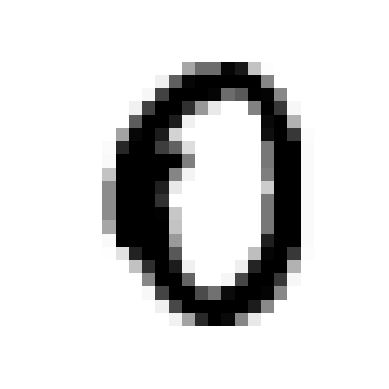

In [20]:
showimage(test_img_copy,0)

In [24]:
LogisticRegr.predict(test_img[2].reshape(1,-1))

array(['1'], dtype=object)

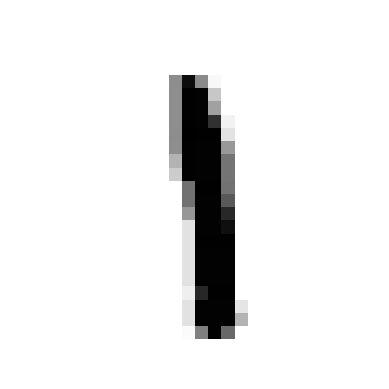

In [23]:
showimage(test_img_copy,2)

Modelimizin doğruluk oranı(accuracy) ölçmek

In [25]:
#Modelimizin doğruluk oranı(accuracy) ölçmek için score metodunu kullanabiliriz:
LogisticRegr.score(test_img,test_lbl)

0.9185

### Sonuç Değerlendirme

Bu projede PCA kullanarak logistic regression tarafından yapay zekanın eğitilme süresini önemli ölçüde kısaltık. Ben %95 variance korumayı hedefledim. Siz çok büyük ölçüde kısaltan PCA algoritması yüzlerce hatta binlerce değişik nesne tipi için yapay zekanın eğitim süresini saatler mertebesinden kısaltacak ve bu da sizin programlarınızı çok daha hızlı çalışmasını sağlayacaktır.

Bu proje ile birbirinden tamamen farklı 2 makine öğrenme modelini bir araya getirip günlük hayatta karşımıza çıkabilecek bir işi bilgisayarlarımıza yapay zeka programı yazarak gerçekleştirdik!

Gerçekten düşününce süper bir teknoloji, el yazısıyla rakamları otomatik olarak tanıyıp bunu bilgisayarın anlayabilceği dijital bir sayı karakterine dönüştürrebiliyoruz! Biraz üzerinde düşünürseniz böyle bir teknoloji kullanarak çok çeşitli icatlar ve ürünler çıkartabilirsiniz. Mesela ... buu projeyi biraz daha geliştirip (alfabedeki harfleri de ekleyip) otomatik olarak el yazısı ile yazılmış dilekçeleri okuyan ve dijital Microsoft Word dosyasına veya PDF dosyasına dönüştüren bir software oluşturabilirsiniz. insanlar fotoğraflarını çekerek oluşturduğu bir dilekçeyi otomatik olarak sisteminize yükleyebilir ve siz de veritabanına metin olarak kaydedebilirsiniz. Aradaki bir çok manuel adımı yapay zeka sayesinde atlamış olursunuz!


In [ ]:
#PCA faydaları: 
#1. Veri setindeki gürültüyü azaltarak modelin daha iyi öğrenmesini sağlar.
#2. Veri setindeki önemli özellikleri koruyarak modelin daha hızlı çalışmasını sağlar
#3. Veri setindeki özellikler arasındaki ilişkileri ortaya çıkararak modelin daha iyi genelleme yapmasını sağlar.
#4. Veri setindeki özelliklerin sayısını azaltarak modelin daha az bellek kullanmasını sağlar.
#5. Veri setindeki özelliklerin sayısını azaltarak modelin daha az overfitting yapmasını sağlar.
#6. Veri setindeki özelliklerin sayısını azaltarak modelin daha az hesaplama yapmasını sağlar.